In [1]:
pip install nltk spacy gensim scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nltk
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import re

In [4]:
nltk.download('brown')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\sabah\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sabah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sabah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

## Partie I: Prétraitement et étiquetage des catégories grammaticales (POS tagging)

In [5]:
from nltk.corpus import brown
from nltk.tag import UnigramTagger, BigramTagger, DefaultTagger
from nltk import CFG, ChartParser
from gensim.models import Word2Vec, KeyedVectors
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

Préparer données

In [6]:
train_sents = brown.tagged_sents(categories='news')[:4000]
test_sents = brown.tagged_sents(categories='news')[4000:4500]

Entraîner et Évaluer Unigram et Bigram

In [7]:
# UnigramTagger
unigram = UnigramTagger(train_sents)
unigram_accuracy = unigram.accuracy(test_sents)
print(f"UnigramTagger accuracy: {unigram_accuracy:.4f}")
# BigramTagger avec backoff
bigram = BigramTagger(train_sents, backoff=unigram)
bigram_accuracy = bigram.accuracy(test_sents)
print(f"BigramTagger (avec backoff) accuracy: {bigram_accuracy:.4f}")

UnigramTagger accuracy: 0.8092
BigramTagger (avec backoff) accuracy: 0.8178


In [8]:
# Exemple d'étiquetage
# 3. Évaluation sur différents genres
print("\n--- Évaluation sur différents genres ---")
genres = ['news', 'editorial', 'religion', 'learned']
results = []

for genre in genres:
    test_genre = brown.tagged_sents(categories=genre)[:500]
    acc = bigram.accuracy(test_genre)
    results.append({'Genre': genre, 'Accuracy': acc})
    print(f"{genre}: {acc:.4f}")


--- Évaluation sur différents genres ---
news: 0.9787
editorial: 0.8309
religion: 0.8067
learned: 0.7290


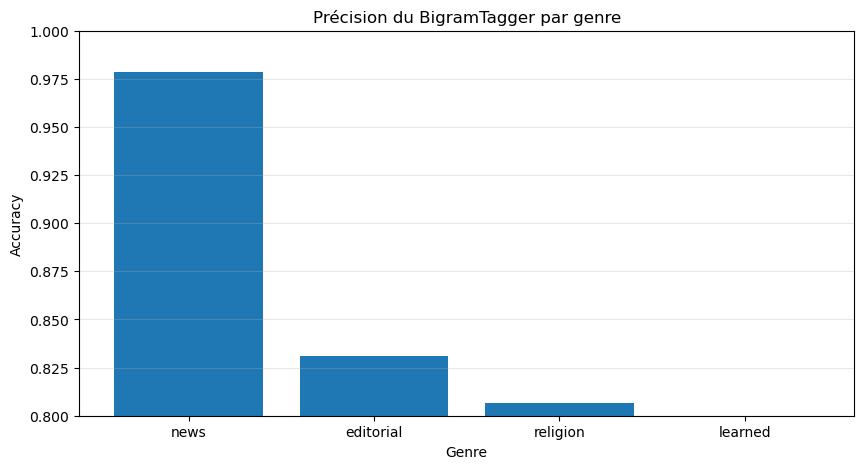

In [9]:
# Visualisation
df_genres = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
plt.bar(df_genres['Genre'], df_genres['Accuracy'])
plt.title('Précision du BigramTagger par genre')
plt.ylabel('Accuracy')
plt.xlabel('Genre')
plt.ylim([0.8, 1.0])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
# 4. Exemple d'étiquetage
print("\n--- Exemple d'étiquetage ---")
example_text = "The professor explains the lesson to students".split()
tagged = bigram.tag(example_text)
print(f"Texte: {' '.join(example_text)}")
print(f"Étiqueté: {tagged}")


--- Exemple d'étiquetage ---
Texte: The professor explains the lesson to students
Étiqueté: [('The', 'AT'), ('professor', 'NN'), ('explains', 'VBZ'), ('the', 'AT'), ('lesson', 'NN'), ('to', 'TO'), ('students', 'NNS')]


In [11]:
# Baseline: DefaultTagger
default_tagger = DefaultTagger('NN')
default_accuracy = default_tagger.accuracy(test_sents)
print(f"DefaultTagger (baseline) accuracy: {default_accuracy:.4f}")

DefaultTagger (baseline) accuracy: 0.1114


Comparaison: l'accuracy de baseline( DefaultTagge) est trés faible par rapport a unigram et Bigram

Reponses aux questions :
..L'utilité de backoff: le BigramTagger ne connaît pas tous les couples de mots.
Quand il ne trouve pas un bigramme, il revient au UnigramTagger qui, lui, connaît plus de cas.
..L'erreurs fréquentes observées sur les noms propres ou les verbes conjugués:
Les noms propres sont souvent mal étiquetés comme noms communs (NN).
Les verbes conjugués rares sont confondus avec des noms ou des adjectifs.
Les modèles basés sur les fréquences confondent forme inconnue = catégorie la plus fréquente.
..Le déséquilibre des étiquettes affecte la performance: Si une étiquette apparaît beaucoup plus que les autres, le modèle a tendance à toujours prédire cette étiquette, car cela maximise l’exactitude.

## Partie II: Analyse syntaxique : constituants et dépendances

### A. Analyse en constituants (arbre de phrases)

In [12]:
grammar_fr = CFG.fromstring("""
    S -> NP VP
    NP -> Det N | Det Adj N | Det N PP | PropN | Pro
    VP -> V NP | V NP PP | V PP | V Adj | V
    PP -> P NP
    
    Det -> 'le' | 'la' | 'les' | 'un' | 'une' | 'des'
    N -> 'professeur' | 'leçon' | 'chat' | 'souris' | 'livre' | 'homme' | 'télescope' | 'jardin'
    PropN -> 'Jean' | 'Marie' | 'Paris'
    Pro -> 'je' | 'tu' | 'il' | 'elle'
    V -> 'explique' | 'mange' | 'lit' | 'vois' | 'donne'
    Adj -> 'grand' | 'petit' | 'rouge' | 'joli'
    P -> 'avec' | 'dans' | 'sur' | 'à' | 'de'
""")

parser = ChartParser(grammar_fr)
# Exemple 1: Phrase simple
print("\nPhrase simple")
phrase1 = "le professeur explique la leçon".split()
print(f"Phrase: {' '.join(phrase1)}")
for tree in parser.parse(phrase1):
    print(tree)
    tree.pretty_print()


Phrase simple
Phrase: le professeur explique la leçon
(S
  (NP (Det le) (N professeur))
  (VP (V explique) (NP (Det la) (N leçon))))
                      S                  
      ________________|______             
     |                       VP          
     |                 ______|___         
     NP               |          NP      
  ___|______          |       ___|____    
Det         N         V     Det       N  
 |          |         |      |        |   
 le     professeur explique  la     leçon



In [13]:
# Exemple 2: Phrase ambiguë
print("\nPhrase ambiguë")
phrase2 = "je vois le homme avec le télescope".split()
print(f"Phrase: {' '.join(phrase2)}")
print("Interprétation 1: Je vois [l'homme avec le télescope]")
print("Interprétation 2: Je vois [l'homme] [avec le télescope]")

trees = list(parser.parse(phrase2))
for i, tree in enumerate(trees, 1):
    print(f"\nArbre {i}:")
    tree.pretty_print()


Phrase ambiguë
Phrase: je vois le homme avec le télescope
Interprétation 1: Je vois [l'homme avec le télescope]
Interprétation 2: Je vois [l'homme] [avec le télescope]

Arbre 1:
     S                                       
  ___|_____________                           
 |                 VP                        
 |    _____________|_________                 
 |   |        |              PP              
 |   |        |          ____|___             
 NP  |        NP        |        NP          
 |   |     ___|____     |     ___|______      
Pro  V   Det       N    P   Det         N    
 |   |    |        |    |    |          |     
 je vois  le     homme avec  le     télescope


Arbre 2:
     S                                   
  ___|_________                           
 |             VP                        
 |    _________|____                      
 |   |              NP                   
 |   |     _________|____                 
 |   |    |    |         PP              
 |

Reponses aux questions :
..Limites des CFG pour le français réel:
Elles ne gèrent pas les accords (genre, nombre, temps).
Elles ne couvrent pas les phrases complexes.
Elles ne résolvent pas les ambiguïtés.

..Exemple d'ambiguïté:« Je vois l’homme avec le télescope. »
Deux interprétations :
 Je vois [l'homme avec le télescope] → L'homme possède le télescope.
 
 Je vois [l'homme] [avec le télescope] → J'utilise le télescope pour voir.
 
Les CFG ne peuvent pas décider entre les deux → besoin de statistiques, contexte, ou dépendances.

### B. Analyse en dépendances

In [18]:
!python -m spacy download fr_core_news_sm

     ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
     - -------------------------------------- 0.5/16.3 MB 2.1 MB/s eta 0:00:08
     -- ------------------------------------- 1.0/16.3 MB 2.2 MB/s eta 0:00:08
     --- ------------------------------------ 1.6/16.3 MB 2.2 MB/s eta 0:00:07
     ----- ---------------------------------- 2.1/16.3 MB 2.4 MB/s eta 0:00:06
     ------- -------------------------------- 2.9/16.3 MB 2.6 MB/s eta 0:00:06
     --------- ------------------------------ 3.7/16.3 MB 2.8 MB/s eta 0:00:05
     ---------- ----------------------------- 4.5/16.3 MB 2.9 MB/s eta 0:00:05
     ------------ --------------------------- 5.0/16.3 MB 3.0 MB/s eta 0:00:04
     ------------ --------------------------- 5.2/16.3 MB 2.8 MB/s eta 0:00:04
     ------------- -------------------------- 5.5/16.3 MB 2.5 MB/s eta 0:00:05
     ------------- -------------------------- 5.5/16.3 MB 2.5 MB/s

In [14]:
import spacy
nlp = spacy.load("fr_core_news_sm")
def extraire_triplets(doc):
    """Extrait les triplets (sujet, verbe, objet) d'un document spaCy"""
    triplets = []
    
    for token in doc:
        if token.pos_ == "VERB":
            sujet = None
            objet = None
            
            for child in token.children:
                if child.dep_ in ("nsubj", "nsubj:pass"):
                    sujet = child.text
                elif child.dep_ in ("obj", "dobj"):
                    objet = child.text
            
            if sujet and objet:
                triplets.append({
                    'sujet': sujet,
                    'verbe': token.lemma_,
                    'objet': objet
                })
    
    return triplets

phrases_test = [
    "La fille lit un livre.",
    "Le professeur explique la leçon aux étudiants.",
]
print("\n--- Analyse en dépendances ---")
for phrase in phrases_test:
    print(f"\nPhrase: {phrase}")
    doc = nlp(phrase)
    
    print("Dépendances:")
    for token in doc:
        print(f"  {token.text:15} | {token.dep_:10} | head: {token.head.text}")
    
    #2. Extraction de triplets
    triplets = extraire_triplets(doc)
    if triplets:
        print("Triplets extraits:")
        for t in triplets:
            print(f"  ({t['sujet']}, {t['verbe']}, {t['objet']})")



--- Analyse en dépendances ---

Phrase: La fille lit un livre.
Dépendances:
  La              | det        | head: fille
  fille           | ROOT       | head: fille
  lit             | amod       | head: fille
  un              | det        | head: livre
  livre           | ROOT       | head: livre
  .               | punct      | head: livre

Phrase: Le professeur explique la leçon aux étudiants.
Dépendances:
  Le              | det        | head: professeur
  professeur      | nsubj      | head: explique
  explique        | ROOT       | head: explique
  la              | det        | head: leçon
  leçon           | obj        | head: explique
  aux             | case       | head: étudiants
  étudiants       | obl:arg    | head: explique
  .               | punct      | head: explique
Triplets extraits:
  (professeur, expliquer, leçon)


1.la dépendance nsubj peut être trompeuse si on a :

Phrase passive:
« Le livre est lu par l’élève. »  → nsubj(lu, livre) mais le livre n’est pas l’agent.

Verbes impersonnels:
« Il pleut. » → nsubj(pleut, il) mais “il” n’a pas de sens réel.

Relatives / phrases longues:
« Le livre que Paul lit… » → le vrai sujet peut être loin du verbe.

2.traitement des phrases à sujet implicite:
Utiliser la conjugaison du verbe:  « Mange ! » → sujet = tu

S’appuyer sur le contexte:   « Suis allé au marché. » → sujet implicite = je

Accepter l’absence de sujet si non déductible (ne pas forcer une extraction incorrecte)

## Partie III: Reconnaissance des entités nommées (NER)

In [15]:
#1.
phrases_ner = [
    "Apple a annoncé l'iPhone 16 en Californie en 2025.",
    "Emmanuel Macron rencontre Joe Biden à Paris.",
    "Google et Microsoft investissent dans l'IA.",
    "Le 14 juillet 1789, la Bastille fut prise.",
]

print("\n--- Reconnaissance d'entités avec spaCy ---")
for phrase in phrases_ner:
    print(f"\nPhrase: {phrase}")
    doc = nlp(phrase)
    
    if doc.ents:
        print("Entités détectées:")
        for ent in doc.ents:
            print(f"  {ent.text:20} | {ent.label_:10}")
    else:
        print("  Aucune entité détectée")


--- Reconnaissance d'entités avec spaCy ---

Phrase: Apple a annoncé l'iPhone 16 en Californie en 2025.
Entités détectées:
  Apple                | ORG       
  iPhone 16            | MISC      
  Californie           | LOC       

Phrase: Emmanuel Macron rencontre Joe Biden à Paris.
Entités détectées:
  Paris                | LOC       

Phrase: Google et Microsoft investissent dans l'IA.
Entités détectées:
  Google               | ORG       
  Microsoft            | ORG       

Phrase: Le 14 juillet 1789, la Bastille fut prise.
Entités détectées:
  la Bastille          | LOC       


In [18]:
# Ajout de règles pour les dates
def extraire_dates_regex(texte):
    patterns = [
        r'\b\d{1,2}/\d{1,2}/\d{4}\b',  # JJ/MM/AAAA
        r'\b\d{1,2} [a-zéû]+ \d{4}\b',  # JJ mois AAAA
        r'\ben \d{4}\b',  # en AAAA
    ]
    
    dates = []
    for pattern in patterns:
        matches = re.finditer(pattern, texte, re.IGNORECASE)
        dates.extend([m.group() for m in matches])
    
    return dates

for phrase in phrases_ner:
    dates = extraire_dates_regex(phrase)
    if dates:
        print(f"\n{phrase}")
        print(f"Dates détectées par regex: {dates}")


Apple a annoncé l'iPhone 16 en Californie en 2025.
Dates détectées par regex: ['en 2025']

Le 14 juillet 1789, la Bastille fut prise.
Dates détectées par regex: ['14 juillet 1789']


1. Les entités difficiles à reconnaître sont :

Les produits, œuvres et événements car ils peuvent ressembler à des noms communs
et nécessitent souvent du contexte pour être identifiés correctement.


2. Les noms ambigus posent problème car:
Exemple : Apple

fruit → nom commun

entreprise → organisation

Le modèle peut se tromper sans contexte.

Solutions :

utiliser le contexte (verbes comme annoncer, vendre)

ajouter des règles ou listes (gazetteers)

utiliser des modèles entraînés sur plus de données

combiner statistique + règles

## Partie IV: Relations de dépendance grammaticales & extraction d'information

In [19]:
#1. Extraction de toutes les relations:
with open("corpus_francais_TP_50 (1).txt", encoding="utf-8") as f:
    text = f.read()
import spacy
import pandas as pd

nlp = spacy.load("fr_core_news_sm")

def extract_svo(text):
    doc = nlp(text)
    relations = []

    for sent in doc.sents:
        for token in sent:
            if token.dep_ == "ROOT" and token.pos_ == "VERB":
                sujet = None
                objet = None

                for child in token.children:
                    if child.dep_ == "nsubj":
                        sujet = child.text
                    if child.dep_ in ("obj", "dobj"):
                        objet = child.text

                if sujet and objet:
                    relations.append({
                        "sujet": sujet,
                        "verbe": token.lemma_,   
                        "objet": objet,
                        "confiance": 1.0        
                    })

    return relations
relations = extract_svo(text)
print(relations)

#créer le CSV
df = pd.DataFrame(relations)
df.to_csv("relations_svo.csv", index=False)

df

[{'sujet': 'gouvernement', 'verbe': 'annoncer', 'objet': 'série', 'confiance': 1.0}, {'sujet': 'équipe', 'verbe': 'remporter', 'objet': 'match', 'confiance': 1.0}, {'sujet': 'marchés', 'verbe': 'connaître', 'objet': 'hausse', 'confiance': 1.0}, {'sujet': 'gouvernement', 'verbe': 'annoncer', 'objet': 'série', 'confiance': 1.0}, {'sujet': 'équipe', 'verbe': 'remporter', 'objet': 'match', 'confiance': 1.0}, {'sujet': 'marchés', 'verbe': 'connaître', 'objet': 'hausse', 'confiance': 1.0}, {'sujet': 'gouvernement', 'verbe': 'annoncer', 'objet': 'série', 'confiance': 1.0}, {'sujet': 'équipe', 'verbe': 'remporter', 'objet': 'match', 'confiance': 1.0}, {'sujet': 'marchés', 'verbe': 'connaître', 'objet': 'hausse', 'confiance': 1.0}, {'sujet': 'gouvernement', 'verbe': 'annoncer', 'objet': 'série', 'confiance': 1.0}, {'sujet': 'équipe', 'verbe': 'remporter', 'objet': 'match', 'confiance': 1.0}, {'sujet': 'marchés', 'verbe': 'connaître', 'objet': 'hausse', 'confiance': 1.0}, {'sujet': 'gouvernement

,sujet,verbe,objet,confiance
0,gouvernement,annoncer,série,1.0
1,équipe,remporter,match,1.0
2,marchés,connaître,hausse,1.0
3,gouvernement,annoncer,série,1.0
4,équipe,remporter,match,1.0
5,marchés,connaître,hausse,1.0
6,gouvernement,annoncer,série,1.0
7,équipe,remporter,match,1.0
8,marchés,connaître,hausse,1.0
9,gouvernement,annoncer,série,1.0


1. Heuristiques pour augmenter la confiance d’une relation extraite:

Donner plus de confiance aux relations avec verbe ROOT

Vérifier la présence simultanée de nsubj et obj

Favoriser les phrases simples (une seule action)

Réduire la confiance si la phrase est longue ou complexe

Utiliser la lemmatisation pour éviter les doublons

2. Gérer les relations implicites ou sur plusieurs phrases

Utiliser le contexte (phrase précédente)

Appliquer la coréférence (pronoms : il, elle, ils)

Fusionner les informations de phrases successives

Accepter que certaines relations ne soient pas explicitement exprimées

## Partie V: Représentations vectorielles : Word2Vec et GloVe

### A. Word2Vec (avec Gensim)

In [20]:
# Préparation du corpus
sentences = [[w.lower() for w in sent] for sent in brown.sents()[:10000]]
print(f"Nombre de phrases pour l'entraînement: {len(sentences)}")

# Entraînement du modèle
model_w2v = Word2Vec(
    sentences, 
    vector_size=100, 
    window=5, 
    min_count=5, 
    workers=4, 
    sg=1  # Skip-gram
)
# Tests de similarité
test_words = ['king', 'queen', 'man', 'woman', 'paris', 'france']
for word in test_words:
    if word in model_w2v.wv:
        similar = model_w2v.wv.most_similar(word, topn=5)
        print(f"\n{word}:")
        for sim_word, score in similar:
            print(f"  {sim_word:15} | {score:.4f}")

Nombre de phrases pour l'entraînement: 10000


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



king:
  atlanta         | 0.9872
  dean            | 0.9869
  howard          | 0.9859
  carl            | 0.9848
  rev.            | 0.9839

queen:
  tall            | 0.9907
  anderson        | 0.9886
  formerly        | 0.9884
  treasurer       | 0.9883
  morris          | 0.9881

man:
  god             | 0.9287
  word            | 0.9045
  life            | 0.9038
  face            | 0.8945
  young           | 0.8907

woman:
  title           | 0.9927
  baby            | 0.9915
  panel           | 0.9908
  style           | 0.9905
  door            | 0.9894

paris:
  16              | 0.9945
  detroit         | 0.9933
  multnomah       | 0.9932
  19              | 0.9930
  1927            | 0.9925

france:
  farmers         | 0.9916
  inspired        | 0.9906
  government's    | 0.9900
  crew            | 0.9896
  core            | 0.9889


1. l'analogie roi - homme + femme = ? fonctionne parfois mal car:

Le Brown corpus est petit et ancien → relations incomplètes

Les analogies supposent des relations linéaires, ce qui n’est pas toujours vrai

Les mots ont plusieurs sens selon le contexte

La qualité dépend fortement du corpus d’entraînement

 Word2Vec apprend des co-occurrences, pas des règles logiques.

2. Les biais qui peuvent être encodés dans ces vecteurs est :

Biais de genre (ex. femme associée à certains rôles, homme à d’autres)

Biais culturels et sociaux présents dans le corpus

Biais temporels (corpus ancien comme Brown)

Stéréotypes linguistiques liés aux fréquences des mots

## B. GloVe

In [28]:
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

print("Conversion GloVe → Word2Vec...")
glove_input = 'glove.6B.100d.txt'
word2vec_output = 'glove.6B.100d.txt.word2vec'
glove2word2vec(glove_input, word2vec_output)
print("Conversion terminée")
wv_glove = KeyedVectors.load_word2vec_format(word2vec_output)
print(f" {len(wv_glove)} mots chargés")


Conversion GloVe → Word2Vec...


C:\Users\sabah\AppData\Local\Temp\ipykernel_19048\85971811.py:7: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input, word2vec_output)


Conversion terminée
 400000 mots chargés


In [24]:
test_word = 'paris'
print(f"\nVoisins de '{test_word}' avec Word2Vec (Brown) ---")
if test_word in model_w2v.wv:
    for word, score in model_w2v.wv.most_similar(test_word, topn=5):
        print(f"  {word:15} {score:.4f}")
else:
    print(f"'{test_word}' absent du vocabulaire")

print(f"\nVoisins de '{test_word}' avec GloVe (pré-entraîné) ---")
if test_word in wv_glove:
    for word, score in wv_glove.most_similar(test_word, topn=5):
        print(f"  {word:15} {score:.4f}")

Word2Vec (Brown) :
[('16', 0.994485080242157), ('detroit', 0.9933156371116638), ('multnomah', 0.9931790828704834), ('19', 0.9929958581924438), ('1927', 0.9925109148025513)]

GloVe pré-entraîné :
[('prohertrib', 0.7994135618209839), ('france', 0.7481585741043091), ('london', 0.7337676882743835), ('brussels', 0.7037922143936157), ('french', 0.6930580735206604)]


## Partie VI: Similarité sémantique et analogies (applications pratiques)

In [54]:
# Mesure 1 : Similarité Cosinus (Standard)
def similarite_cosinus(phrase1, phrase2, model):
    """Angle entre vecteurs moyens"""
    words1 = [w.lower() for w in phrase1.split() if w.lower() in model.wv]
    words2 = [w.lower() for w in phrase2.split() if w.lower() in model.wv]
    
    if not words1 or not words2:
        return 0.0
    
    vec1 = np.mean([model.wv[w] for w in words1], axis=0)
    vec2 = np.mean([model.wv[w] for w in words2], axis=0)
    
    return cosine_similarity([vec1], [vec2])[0][0]

# Mesure 2 : Distance Euclidienne
def similarite_euclidienne(phrase1, phrase2, model):
    """Distance géométrique"""
    words1 = [w.lower() for w in phrase1.split() if w.lower() in model.wv]
    words2 = [w.lower() for w in phrase2.split() if w.lower() in model.wv]
    
    if not words1 or not words2:
        return 0.0
    
    vec1 = np.mean([model.wv[w] for w in words1], axis=0)
    vec2 = np.mean([model.wv[w] for w in words2], axis=0)
    
    distance = np.linalg.norm(vec1 - vec2)
    return 1 / (1 + distance)

# Mesure 3 : Alignement maximal
def similarite_alignement(phrase1, phrase2, model):
    """Meilleur match pour chaque mot"""
    words1 = [w.lower() for w in phrase1.split() if w.lower() in model.wv]
    words2 = [w.lower() for w in phrase2.split() if w.lower() in model.wv]
    
    if not words1 or not words2:
        return 0.0
    
    scores = []
    for w1 in words1:
        max_sim = max([model.wv.similarity(w1, w2) for w2 in words2])
        scores.append(max_sim)
    
    return np.mean(scores)

paires = [
    # Paraphrases (très similaires)
    ("The cat is sleeping", "A cat sleeps", "paraphrase"),
    ("I love chocolate", "I like chocolate", "paraphrase"),
    ("Paris is beautiful", "Paris is a nice city", "paraphrase"),
    
    # Similaires
    ("The dog plays in the garden", "A dog runs in the park", "similaire"),
    ("I am reading a book", "She is studying", "similaire"),
    ("The weather is nice today", "It is sunny outside", "similaire"),
    ("He drives a car", "She owns a vehicle", "similaire"),
    
    # Thématiques
    ("I need to buy groceries", "The supermarket is nearby", "thématique"),
    ("The movie was exciting", "I enjoyed the film", "thématique"),
    ("She is a doctor", "He works in a hospital", "thématique"),
    ("The train arrives at noon", "I will catch the bus", "thématique"),
    
    # Opposées
    ("I love programming", "I hate coding", "opposé"),
    ("The weather is hot", "It is freezing cold", "opposé"),
    ("He is very tall", "She is extremely short", "opposé"),
    ("The room is bright", "The space is dark", "opposé"),
    
    # Non liées
    ("I like pizza", "The sky is blue", "non-lié"),
    ("She plays piano", "He repairs computers", "non-lié"),
    ("The cat is black", "Mathematics is difficult", "non-lié"),
    ("Trees are green", "I bought a new phone", "non-lié"),
]
categories = {}
for _, _, cat in paires:
    categories[cat] = categories.get(cat, 0) + 1

print("\nRépartition:")
for cat, count in categories.items():
    print(f"  - {cat}: {count} paires")

resultats = []

for phrase1, phrase2, categorie in paires:
    cos = similarite_cosinus(phrase1, phrase2, model_w2v)
    euc = similarite_euclidienne(phrase1, phrase2, model_w2v)
    align = similarite_alignement(phrase1, phrase2, model_w2v)
    
    resultats.append({
        'Phrase 1': phrase1,
        'Phrase 2': phrase2,
        'Catégorie': categorie,
        'Cosinus': cos,
        'Euclidienne': euc,
        'Alignement': align
    })

df = pd.DataFrame(resultats)
print(df)


Répartition:
  - paraphrase: 3 paires
  - similaire: 4 paires
  - thématique: 4 paires
  - opposé: 4 paires
  - non-lié: 4 paires
                       Phrase 1                   Phrase 2   Catégorie  \
0           The cat is sleeping               A cat sleeps  paraphrase   
1              I love chocolate           I like chocolate  paraphrase   
2            Paris is beautiful       Paris is a nice city  paraphrase   
3   The dog plays in the garden     A dog runs in the park   similaire   
4           I am reading a book            She is studying   similaire   
5     The weather is nice today        It is sunny outside   similaire   
6               He drives a car         She owns a vehicle   similaire   
7       I need to buy groceries  The supermarket is nearby  thématique   
8        The movie was exciting         I enjoyed the film  thématique   
9               She is a doctor     He works in a hospital  thématique   
10    The train arrives at noon       I will catch the 

Améliorations proposées :

Filtrage stopwords → focus sur les mots importants
Pondération TF-IDF → valoriser les mots rares
WMD → alignement optimal
Sentence-BERT → embeddings contextuels